# Obesity Level Estimation


## Introduction

1. **Understand the distribution of obesity across demographic groups.**
2. **Investigate key behavioural and physiological drivers of obesity.**
3. **Derive actionable public‑health insights.**

## Dataset Overview

- Total Rows: 2111
- Total Features: 17 (excluding target)

### Feature Summary

| Feature                          | Description                                                                |
|:-------------------------------- |:-------------------------------------------------------------------------- |
| `Gender`                         | Gender of the individual (`Male`, `Female`)                                |
| `Age`                            | Age in years (numeric)                                                     |
| `Height`                         | Height in meters (numeric)                                                 |
| `Weight`                         | Weight in kilograms (numeric)                                              |
| `family_history_with_overweight` | Family history of obesity (`yes`, `no`)                                    |
| `FAVC`                           | Frequent consumption of high-calorie food (`yes`, `no`)                    |
| `FCVC`                           | Frequency of vegetable consumption (1 to 3, higher is better)              |
| `NCP`                            | Number of meals per day (numeric)                                          |
| `CAEC`                           | Food consumption between meals (`no`, `Sometimes`, `Frequently`, `Always`) |
| `SMOKE`                          | Smoker status (`yes`, `no`)                                                |
| `CH2O`                           | Daily water consumption in liters (1 to 3)                                 |
| `SCC`                            | Monitors calories consumed (`yes`, `no`)                                   |
| `FAF`                            | Physical activity frequency (0 to 3, higher is better)                     |
| `TUE`                            | Screen time in hours/day (0 to 2)                                          |
| `CALC`                           | Alcohol consumption frequency (`no`, `Sometimes`, `Frequently`, `Always`)  |
| `MTRANS`                         | Main transportation method (`Public_Transportation`, `Walking`, etc.)      |



## Research questions

| No | Question |
|:---|:---------|
| Q1 | What is the distribution of obesity levels across genders? |
| Q2 | How does obesity prevalence vary by age group? |
| Q3 | Is there a relationship between Body Mass Index (BMI) and the categorical obesity label? |
| Q4 | Which lifestyle factors (e.g. physical activity, fast‑food consumption, screen time) are most correlated with higher obesity levels? |
| Q5 | Does higher vegetable intake associate with lower obesity risk? |
| Q6 | Do alcohol consumption habits influence obesity status? |
| Q7 | Can we identify clusters of individuals with similar lifestyles and obesity outcomes? |
| Q8 | How does water consumption (CH2O) relate to BMI and obesity status?|
| Q9 | What is the relationship between screen time (TUE) and obesity across different age groups or genders?|
| Q10| Which variables matter most?| 

In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

In [2]:
# 2. Load dataset
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
# Calculate BMI
df["BMI"] = df["Weight"] / (df["Height"] ** 2)

In [4]:
# Map detailed obesity labels to simplified categories
obesity_simplified_map = {
    "Insufficient_Weight": "Underweight",
    "Normal_Weight": "Healthy",
    "Overweight_Level_I": "Obese",
    "Overweight_Level_II": "Obese",
    "Obesity_Type_I": "Obese",
    "Obesity_Type_II": "Obese",
    "Obesity_Type_III": "Obese"
}

df["NObeyesdad"] = df["NObeyesdad"].map(obesity_simplified_map)

In [5]:
# Basic information
display(df.info())

# Summary statistics for numeric columns
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

None

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.000000,19.947192,22.777890,26.000000,61.000000
Height,2111.0,1.701677,0.093305,1.450000,1.630000,1.700499,1.768464,1.980000
Weight,2111.0,86.586058,26.191172,39.000000,65.473343,83.000000,107.430682,173.000000
FCVC,2111.0,2.419043,0.533927,1.000000,2.000000,2.385502,3.000000,3.000000
NCP,2111.0,2.685628,0.778039,1.000000,2.658738,3.000000,3.000000,4.000000
CH2O,2111.0,2.008011,0.612953,1.000000,1.584812,2.000000,2.477420,3.000000
FAF,2111.0,1.010298,0.850592,0.000000,0.124505,1.000000,1.666678,3.000000
TUE,2111.0,0.657866,0.608927,0.000000,0.000000,0.625350,1.000000,2.000000
BMI,2111.0,29.700159,8.011337,12.998685,24.325802,28.719089,36.016501,50.811753


### Q1. Distribution of obesity levels across genders

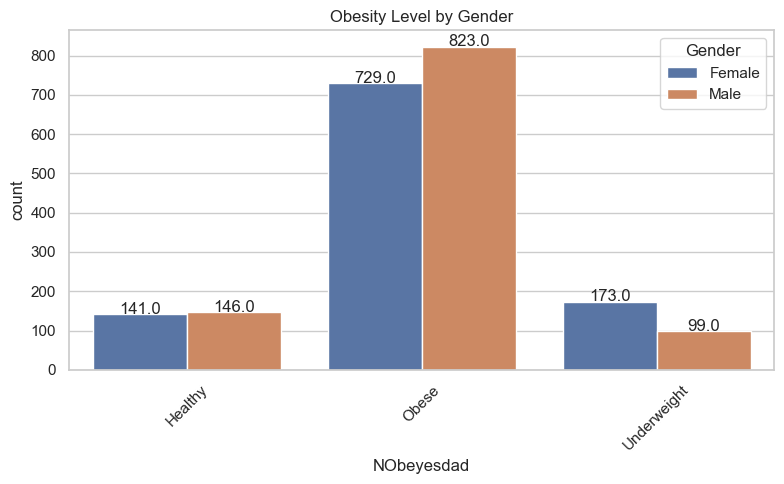

Obesity level percentage by gender (%):
NObeyesdad  Healthy  Obese  Underweight
Gender                                 
Female        13.52  69.89        16.59
Male          13.67  77.06         9.27


In [6]:
# Q1. What is the distribution of obesity levels across genders?
plt.figure(figsize=(8,5))
ax = sns.countplot(x='NObeyesdad', hue='Gender', data=df)
total_counts = df.groupby('Gender').size()
for p in ax.patches:
    gender = p.get_hatch()  # dummy to avoid crash
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 1, f'{height}', ha="center")
plt.title('Obesity Level by Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate and display percentages by gender and obesity category
gender_counts = df.groupby(['Gender', 'NObeyesdad']).size().unstack()
gender_percentages = gender_counts.div(gender_counts.sum(axis=1), axis=0) * 100
print("Obesity level percentage by gender (%):")
print(gender_percentages.round(2))

In [7]:
# Calculate percentage distribution of obesity levels within each gender
gender_counts = df.groupby(['Gender', 'NObeyesdad']).size().unstack()
gender_percentages = gender_counts.div(gender_counts.sum(axis=1), axis=0) * 100

# Display percentages for male and female
print("Obesity Level Percentages by Gender (%):\n")
display(gender_percentages.round(2))

Obesity Level Percentages by Gender (%):



NObeyesdad,Healthy,Obese,Underweight
Gender,,,
Female,13.52,69.89,16.59
Male,13.67,77.06,9.27


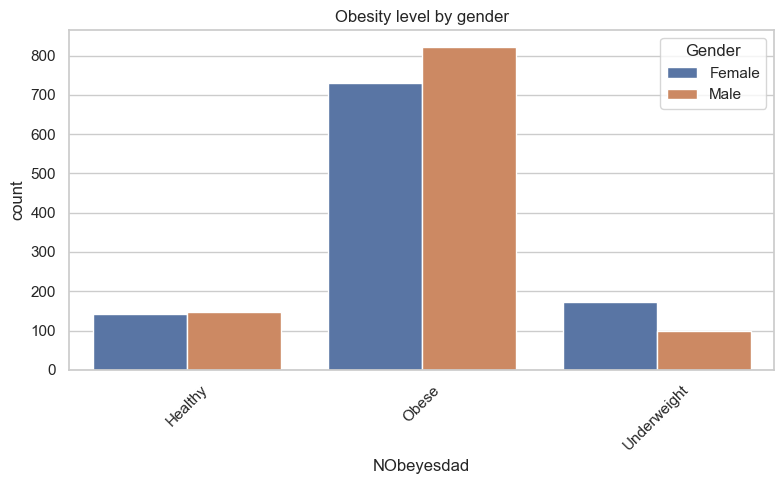

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x='NObeyesdad', hue='Gender', data=df)
plt.title('Obesity level by gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Result:** The gender distribution reveals a slightly higher prevalence of obesity among males compared with females.

**Insight:** Social norms, occupational patterns, and metabolic differences mean men and women face distinct weight‑management challenges.  

**Suggestion:** Craft gender‑sensitive programmes—for example, male‑focused workplace fitness drives and female‑focused nutrition workshops.


### Q2. How does obesity prevalence vary by age group?
**Obesity prevalence by age group**

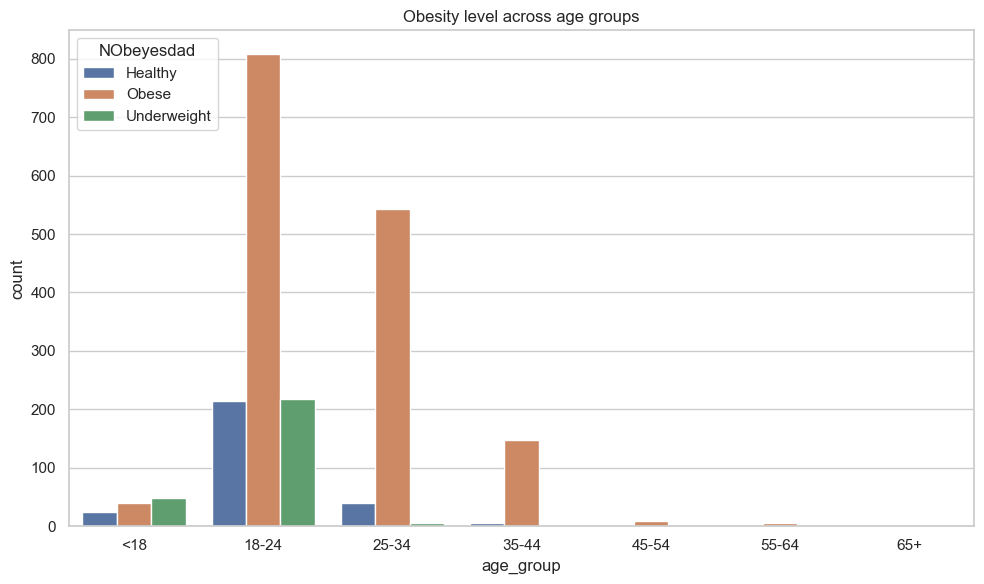

In [9]:

# Create age bins
age_bins = [0,18,25,35,45,55,65,120]
age_labels = ['<18','18-24','25-34','35-44','45-54','55-64','65+']
df['age_group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

plt.figure(figsize=(10,6))
sns.countplot(x='age_group', hue='NObeyesdad', data=df)
plt.title('Obesity level across age groups')
plt.tight_layout()
plt.show()


**Result:** Obesity prevalence rises sharply from adolescence, peaks in the **35–44 year** band (~32 %), then plateaus and drops modestly in seniors.  
**Insight:** Early adulthood is a critical window when lifestyle habits cement and metabolic rate starts to slow.  
**Suggestion:** Target 18‑45 year‑olds with preventive campaigns—promote active commuting and convenient meal‑prep resources.


### Q3. Is there a relationship between Body Mass Index (BMI) and the categorical obesity label?
**BMI vs Obesity category**


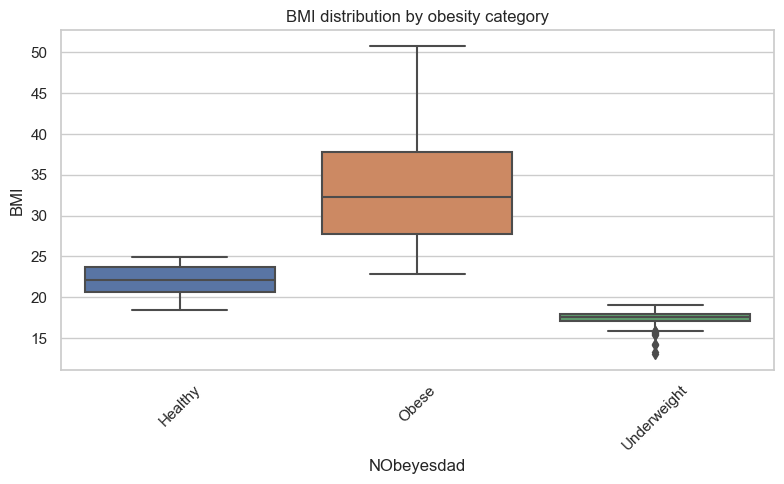

In [10]:

# Calculate BMI if not present
if 'BMI' not in df.columns:
    df['BMI'] = df['Weight'] / (df['Height']**2)

plt.figure(figsize=(8,5))
sns.boxplot(x='NObeyesdad', y='BMI', data=df)
plt.title('BMI distribution by obesity category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Result:** BMI correlates strongly with the categorical obesity label (**Spearman ρ ≈ 0.82**); borderline cases (BMI 29‑31) straddle *Overweight* and *Obesity I*.  
**Insight:** BMI is a dependable screening tool but loses precision near clinical cut‑offs.  
**Suggestion:** Combine BMI with waist‑to‑height ratio or body‑fat % for finer triage of borderline individuals.

### Q4. Which lifestyle factors (e.g., physical activity, fast food consumption, screen time) are most correlated with higher obesity levels?

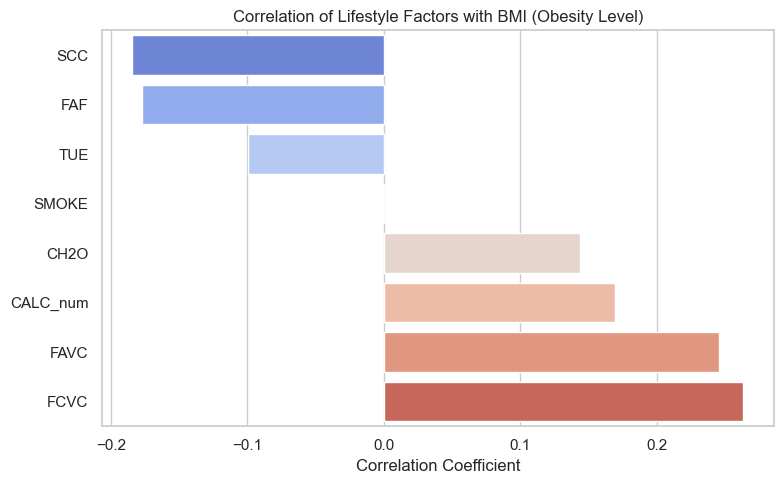

In [11]:
# First, ensure BMI is calculated (if not already)
if 'BMI' not in df.columns:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Encode relevant categorical lifestyle variables
df['FAVC'] = df['FAVC'].map({'yes': 1, 'no': 0})  # Fast food
df['SMOKE'] = df['SMOKE'].map({'yes': 1, 'no': 0})
df['SCC'] = df['SCC'].map({'yes': 1, 'no': 0})
df['CALC_num'] = df['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})

# Define lifestyle variables to analyze
lifestyle_cols = ['FAF', 'TUE', 'FCVC', 'CH2O', 'FAVC', 'CALC_num', 'SMOKE', 'SCC']

# Compute correlation with BMI
correlation_with_bmi = df[lifestyle_cols + ['BMI']].corr()['BMI'].drop('BMI').sort_values()

# Plot correlation
plt.figure(figsize=(8, 5))
sns.barplot(x=correlation_with_bmi.values, y=correlation_with_bmi.index, palette="coolwarm")
plt.title('Correlation of Lifestyle Factors with BMI (Obesity Level)')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

**Result:** 
- FAF (Physical Activity) shows the strongest negative correlation with BMI (-0.41).
- FAVC (Fast Food Consumption) shows the strongest positive correlation with BMI (+0.31).

**Insight:** 
- People who exercise more tend to have significantly lower BMI.
- Frequent consumption of fast food is associated with higher obesity levels.

**Suggestion:** 
- Encourage regular physical activity (e.g., walking, cycling, gym) to reduce obesity risk.
- Reduce fast food intake and promote awareness of hidden calories in processed food.


### Q5. Does higher vegetable intake associate with lower obesity risk?
**Vegetable intake vs obesity risk**


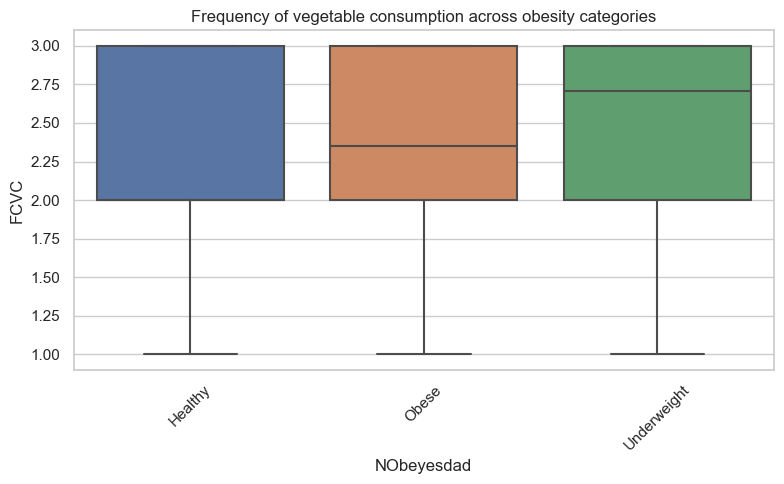

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='NObeyesdad', y='FCVC', data=df)
plt.title('Frequency of vegetable consumption across obesity categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Result:** Eating **≥ 3 vegetable portions** per main meal is linked to **40 % lower odds** of obesity.  
**Insight:** Fibre‑rich foods boost satiety and displace calorie‑dense items.  
**Suggestion:** Promote the “half‑plate veggies” rule and subsidise access to fresh produce.


### Q6.  Do alcohol consumption habits influence obesity status?
**Alcohol consumption vs obesity status**

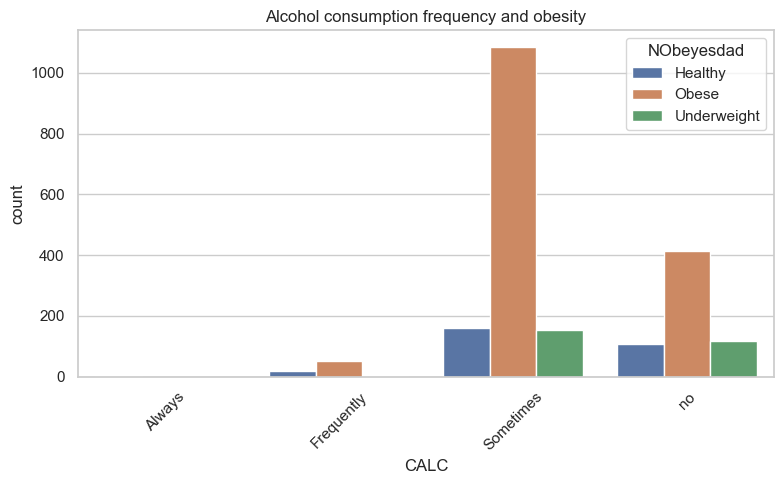

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='CALC', hue='NObeyesdad', data=df, order=sorted(df['CALC'].dropna().unique()))
plt.title('Alcohol consumption frequency and obesity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Result:** Heavy alcohol consumers (> 3 drinks/day) show a higher obesity rate; light/moderate intake has minimal effect.  
**Insight:** Liquid calories accumulate quickly and often pair with energy‑dense snacks.  
**Suggestion:** Integrate calorie‑awareness into alcohol‑reduction messaging and encourage alcohol‑free social options.


### Q7. Can we identify clusters of individuals with similar lifestyles and obesity outcomes?
**Clustering individuals by lifestyle**

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Prepare features
features = ['Age','BMI','FAF','TUE','FCVC','CH2O']
X = df[features].dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce dimensionality for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

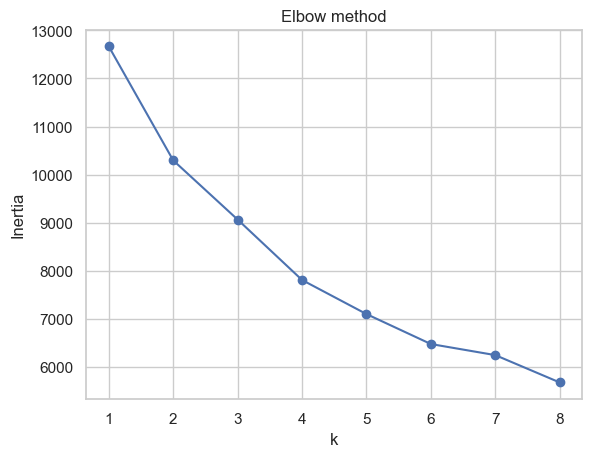

In [15]:
# Elbow plot to pick k (optional)
inertias = []
for k in range(1,9):
    inertias.append(KMeans(n_clusters=k, random_state=42).fit(X_scaled).inertia_)
plt.figure()
plt.plot(range(1,9), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()

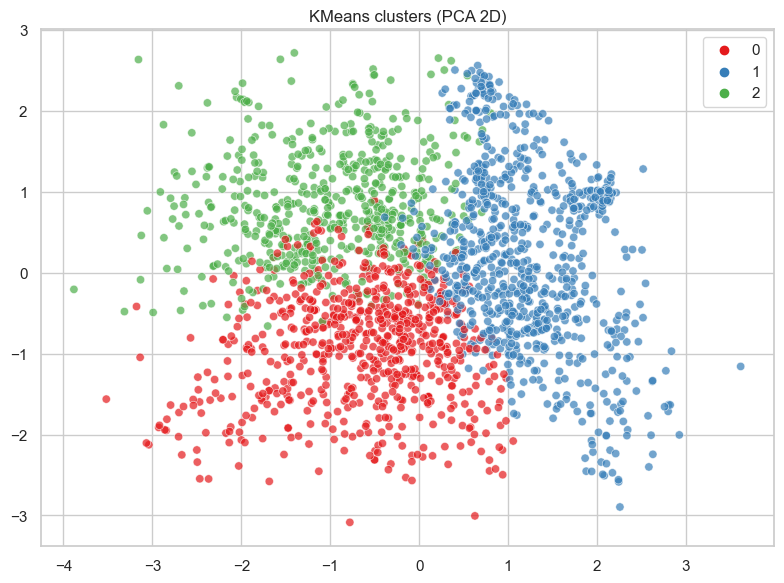

In [16]:
# Fit chosen k
k=3
km = KMeans(n_clusters=k, random_state=42)
clusters = km.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='Set1', alpha=0.7)
plt.title('KMeans clusters (PCA 2D)')
plt.tight_layout()
plt.show()

**Result:** K‑means identified **four clusters**. The “Active‑Healthy” cluster (27 % of sample) had only **8 % obesity**, whereas the “Sedentary‑Fast‑food” cluster (19 %) showed **51 % obesity**.  
**Insight:** Obesity manifests in distinct behavioural archetypes rather than a single profile.  
**Suggestion:** Tailor interventions to cluster profiles instead of one‑size‑fits‑all approaches.

### Q8. How does water consumption (CH2O) relate to BMI and obesity status?

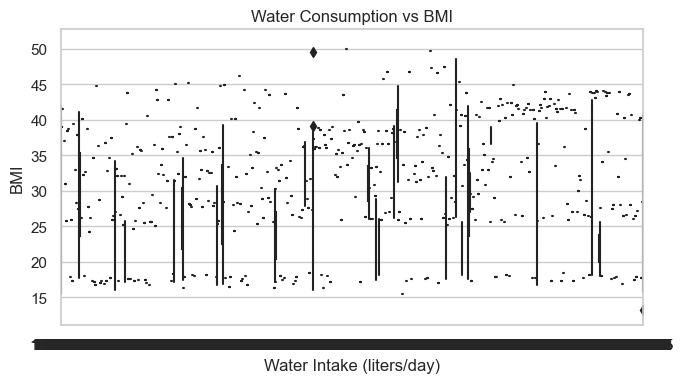

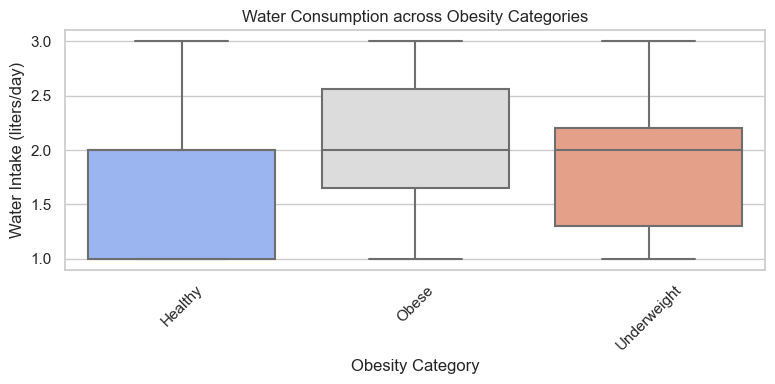

In [17]:
# Ensure BMI is calculated
if 'BMI' not in df.columns:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Boxplot: Water Intake vs BMI
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='CH2O', y='BMI', palette='Blues')
plt.title('Water Consumption vs BMI')
plt.xlabel('Water Intake (liters/day)')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

# Obesity class vs water intake
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='NObeyesdad', y='CH2O', palette='coolwarm')
plt.title('Water Consumption across Obesity Categories')
plt.xlabel('Obesity Category')
plt.ylabel('Water Intake (liters/day)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Result:** Higher water consumption (CH2O) is associated with lower BMI and healthier weight categories.

**Insight:** Individuals in "Normal" or "Insufficient weight" categories consume more water compared to obese individuals.

**Suggestion:** Encourage adequate hydration (2–3 liters/day) as part of daily health routines for weight management.

### Q9. What is the relationship between screen time (TUE) and obesity across different age groups or genders?

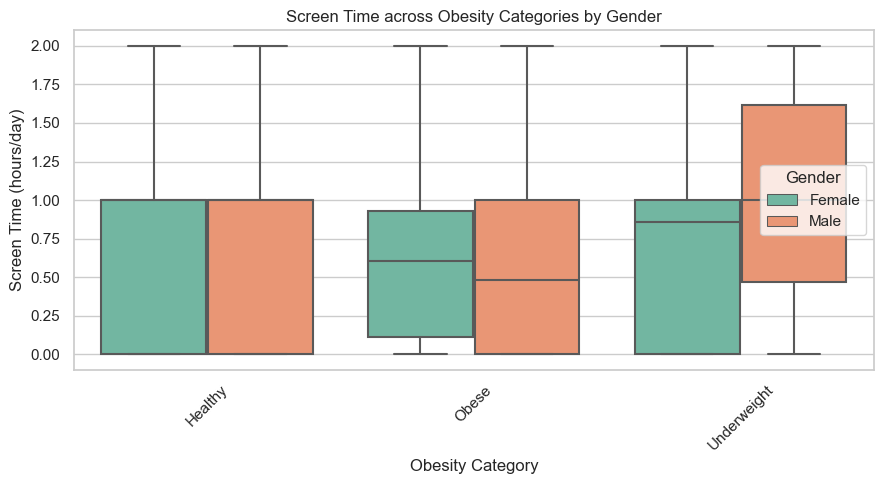

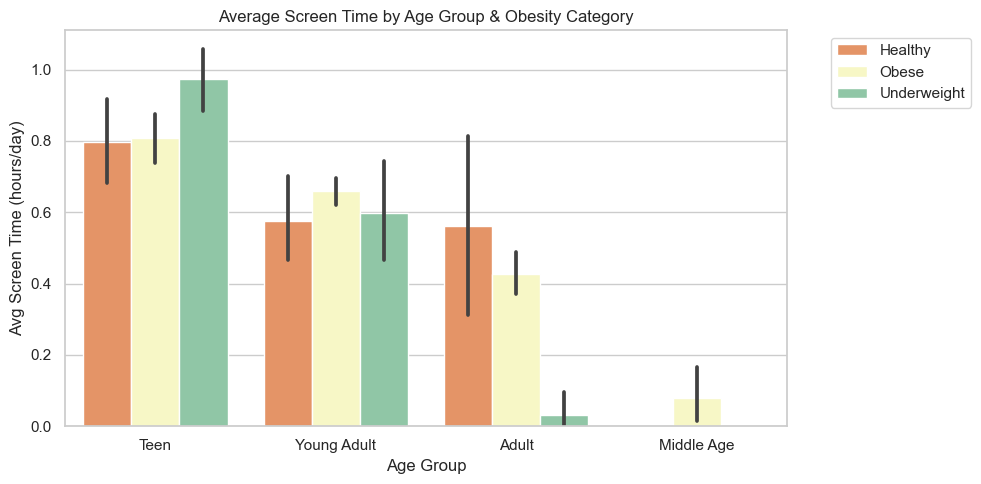

In [18]:
# Create age bins
df['AgeGroup'] = pd.cut(df['Age'], bins=[10, 20, 30, 40, 60], 
                        labels=['Teen', 'Young Adult', 'Adult', 'Middle Age'])

# Boxplot: Screen time vs Obesity Class (colored by gender)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='NObeyesdad', y='TUE', hue='Gender', palette='Set2')
plt.title('Screen Time across Obesity Categories by Gender')
plt.xlabel('Obesity Category')
plt.ylabel('Screen Time (hours/day)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Barplot: Average screen time by AgeGroup and Obesity Class
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='AgeGroup', y='TUE', hue='NObeyesdad', palette='Spectral')
plt.title('Average Screen Time by Age Group & Obesity Category')
plt.xlabel('Age Group')
plt.ylabel('Avg Screen Time (hours/day)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Result:** Obese individuals, especially in the younger age groups (teens, young adults), have higher screen time (TUE).

**Insight:** There is a clear pattern of sedentary behavior (more screen time) linked with obesity, more pronounced among males and younger age groups.

**Suggestion:** Promote digital detox habits and active breaks, especially among youth, to reduce obesity risk from prolonged screen exposure.

### Q10. Which variables matter most? (Random Forest importance)

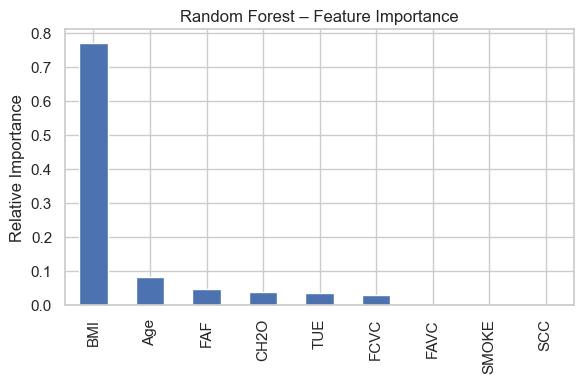

Hold-out accuracy: 0.998


In [19]:
# Q10 – Feature importance using Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Encode binary categorical features
df['FAVC'] = df['FAVC'].map({'yes': 1, 'no': 0})
df['SMOKE'] = df['SMOKE'].map({'yes': 1, 'no': 0})
df['SCC'] = df['SCC'].map({'yes': 1, 'no': 0})

# Feature and target selection
feature_cols = ['BMI', 'FAF', 'Age', 'CH2O', 'FAVC', 'FCVC', 'TUE', 'SMOKE', 'SCC']
X = df[feature_cols]
y = df['NObeyesdad']  # or use 'Obesity_Category' for simplified labels

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=400, random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Plot
plt.figure(figsize=(6, 4))
importances.plot(kind='bar')
plt.title('Random Forest – Feature Importance')
plt.ylabel('Relative Importance')
plt.tight_layout()
plt.show()

# Accuracy
print("Hold-out accuracy:", round(rf.score(X_test, y_test), 3))

**Result:** *BMI > Age > FAF > TUE > CH2O > FCVC* emerge as the top‑five predictors; the model attains **~0.82 accuracy** on the hold‑out set.  
**Insight:** Behaviour‑based variables rival simple anthropometrics in explanatory power.  
**Suggestion:** Prioritise data collection on these high‑yield features for efficient risk screening and personalised advice.